In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mariamali12/e047-dataset/E047_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

# Set seed for reproducibility
torch.manual_seed(1)
np.random.seed(1)

# Data Importing

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mariamali12/e047-dataset/E047_dataset.csv', index_col=0)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,label
ENSG00000000003,1,4,1,0,2,1,1,2,1,0,...,1,2,0,2,0,0,1,1,4,-1
ENSG00000000005,0,1,0,0,1,0,0,0,0,0,...,1,1,2,5,0,0,1,0,2,-1
ENSG00000000419,1,3,6,1,1,2,1,6,2,1,...,4,1,0,1,3,4,4,0,3,1
ENSG00000000457,2,3,4,1,0,1,8,2,3,0,...,3,2,1,4,1,3,2,3,6,1
ENSG00000000460,3,4,3,4,2,3,4,0,2,0,...,5,1,2,1,2,6,3,3,1,1


In [4]:
#Separate features and labels
X = df.drop(columns=['label']).values  # (19300, 500)
y = df['label'].values                 # (19300,) — +1 / -1

# Convert +1/-1 (paper convention) → 1/0 (required by PyTorch NLLLoss)
y = ((y + 1) // 2).astype(int)
print(f"Label distribution: {np.bincount(y)}")  # expect ~[9534, 9766]

Label distribution: [9534 9766]


In [5]:
# Reshape to (19300, 5, 100) 
# CSV layout: columns are [bin1_mark1..5, bin2_mark1..5, ..., bin100_mark1..5]
X = X.reshape(-1, 100, 5)  # (19300, 100, 5)
print(f"Feature shape: {X.shape}")  # expect (19300, 100,  5)

Feature shape: (19300, 100, 5)


In [6]:
# Randomized train / val / test split
np.random.seed(1)
indices = np.random.permutation(len(X))

train_idx = indices[:6601]
val_idx   = indices[6601:13202]
test_idx  = indices[13202:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (6601, 100, 5), Val: (6601, 100, 5), Test: (6098, 100, 5)


In [7]:
# PyTorch Dataset 
class GeneDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
#  DataLoaders
train_loader = DataLoader(GeneDataset(X_train, y_train), batch_size=1,  shuffle=True)
val_loader   = DataLoader(GeneDataset(X_val,   y_val),   batch_size=64, shuffle=False)
test_loader  = DataLoader(GeneDataset(X_test,  y_test),  batch_size=64, shuffle=False)

# Model Buidling

##### Our model implements a Hierarchical Attention Network to predict `Gene expression` utilizing 5 histone marks as features.
##### We will divide the architecture of the model into 3 components:

# 1. **`BinEncoder` : one LSTM per histone mark**


- `Goal`: It draws connection patterns among the bins that represent each bin in the context of all surrounding bins using a bidirectional LSTM.
- `Process`: It consists of 5 independent bidirectional LSTM processes, 100 bins for each mark
- `Input`:  (seq_len=100, batch_size, input_size=1) 

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinEncoder(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, dropout, bidirectional):
        super(BinEncoder, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional
        )

    def forward(self, x):
        # x: (seq_len, batch_size, input_size)
        output, _ = self.lstm(x)           
        output = output.permute(1, 0, 2)  
        return output

# **2. `Attention` : the soft attention mechanism**


- `Goal`: It assigns weight to each bin depending on its importance compared to the Ideal state `context_vector`.
- `Process`: It learns what an important bin looks like during training and assigns it to context_vector, then compares it to each bin using the dot product. The more similar, the higher the weight.
- `Input`:  (batch_size, seq_len, rep_size)

In [9]:
class Attention(nn.Module):

    def __init__(self, rep_size):
        super(Attention, self).__init__()
        # Context vector — learned parameter that scores each position
        self.context_vector = nn.Parameter(
            torch.Tensor(rep_size, 1)
        )
        self.context_vector.data.uniform_(-0.1, 0.1)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # Score each position: (batch_size, seq_len, rep_size) × (rep_size, 1)
        # → (batch_size, seq_len, 1) → squeeze → (batch_size, seq_len)
        scores = torch.bmm(x, self.context_vector.unsqueeze(0)
                           .expand(x.size(0), -1, -1)).squeeze(2)

        # Convert scores to weights that sum to 1
        alpha = self.softmax(scores)       # (batch_size, seq_len)

        # Weighted sum of input vectors
        # alpha: (batch_size, 1, seq_len) × x: (batch_size, seq_len, rep_size)
        # → (batch_size, 1, rep_size)
        representation = torch.bmm(
            alpha.unsqueeze(1), x
        )
        return representation, alpha

# **3. `AttentiveChrome`: the full model**

- AttentiveChrome is where all the components are working together to weigh the histone marks and bins' importance and give a final prediction.
- It does this hierarchically. First, it weighs bins per mark (α attention), then it weighs the 5 marks themselves (β attention). Using hierarchy attention means the model learns to connect to patterns of histones and bins together, not to treat them differently, e.g., "H3K4me3 near the TSS matters most", not just "H3K4me3 matters" or "the TSS region matters". It captures both simultaneously.

In [10]:
class AttentiveChrome(nn.Module):
    def __init__(self, n_bins=100, n_marks=5, hidden_size=32,
                 num_layers=1, dropout=0.5, bidirectional=True):
        super(AttentiveChrome, self).__init__()

        self.n_marks   = n_marks
        self.n_bins    = n_bins
        num_directions = 2 if bidirectional else 1

        # Level 1: one LSTM + attention per histone mark
        self.bin_encoders = nn.ModuleList([
            BinEncoder(
                input_size=1,                  
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout,
                bidirectional=bidirectional
            )
            for _ in range(n_marks)
        ])
        bin_rep_size = hidden_size * num_directions
        self.bin_attention = nn.ModuleList([
            Attention(bin_rep_size) for _ in range(n_marks)
        ])

        # Level 2: one LSTM + attention over the 5 mark representations
        self.mark_encoder = BinEncoder(
            input_size=bin_rep_size,
            hidden_size=hidden_size // 2,     
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional
        )
        mark_rep_size = (hidden_size // 2) * num_directions
        self.mark_attention = Attention(mark_rep_size)

        # Final classifier
        self.classifier = nn.Linear(mark_rep_size, 1)

    def forward(self, x):
        # x: (batch_size, 100, 5)
        batch_size = x.size(0)
        mark_representations = []
        all_bin_alphas = []

        # Level 1: encode each mark's bin sequence
        for i, (encoder, attention) in enumerate(
                zip(self.bin_encoders, self.bin_attention)):

            # Extract mark i across all bins: (batch_size, 100)
            mark_seq = x[:, :, i]

            # Reshape for LSTM: (seq_len=100, batch_size, input_size=1)
            mark_seq = mark_seq.permute(1, 0).unsqueeze(2)

            # Encode: (batch_size, 100, hidden_size*2)
            bin_output = encoder(mark_seq)

            # Attend: weighted representation + alpha weights
            rep, alpha = attention(bin_output)  
            mark_representations.append(rep)
            all_bin_alphas.append(alpha)

        # Stack mark representations: (batch_size, 5, rep_size)
        mark_reps = torch.cat(mark_representations, dim=1)

        # Level 2: encode across marks
        # Reshape for LSTM: (seq_len=5, batch_size, rep_size)
        mark_reps_for_lstm = mark_reps.permute(1, 0, 2)
        mark_output = self.mark_encoder(mark_reps_for_lstm)  
        final_rep, beta = self.mark_attention(mark_output)   

        # Classification 
        final_rep = final_rep.squeeze(1)                     
        out = torch.sigmoid(self.classifier(final_rep))     

        return out, all_bin_alphas, beta

In [11]:
# Verify model output shapes
model = AttentiveChrome()
dummy_input = torch.randn(4, 100, 5)  # batch of 4 genes
pred, bin_alphas, beta = model(dummy_input)

print(f"Prediction shape:       {pred.shape}")         # expect (4, 1)
print(f"Bin alpha shapes:       {bin_alphas[0].shape}") # expect (4, 100)
print(f"Mark beta shape:        {beta.shape}")          # expect (4, 5)
print(f"Number of bin alphas:   {len(bin_alphas)}")     # expect 5

Prediction shape:       torch.Size([4, 1])
Bin alpha shapes:       torch.Size([4, 100])
Mark beta shape:        torch.Size([4, 5])
Number of bin alphas:   5


# Training

In [12]:
#Setup 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


torch.manual_seed(1)
model = AttentiveChrome().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

#Training loop 
n_epochs = 100
train_losses, val_losses, val_aurocs = [], [], []

for epoch in range(1, n_epochs + 1):

    #Train 
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        # BCELoss expects float targets of shape (batch, 1)
        y_batch = y_batch.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        pred, _, _ = model(X_batch)   # we ignore attention weights during training
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    #Validate 
    model.eval()
    val_loss = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.float().unsqueeze(1).to(device)

            pred, _, _ = model(X_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item()

            all_probs.extend(pred.squeeze(1).cpu().numpy())
            all_labels.extend(y_batch.squeeze(1).cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_auroc = roc_auc_score(all_labels, all_probs)
    val_aurocs.append(val_auroc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUROC: {val_auroc:.4f}")

print("\nTraining complete.")

# Early Stopping Hyperparameter

In [13]:
import copy
from torch.optim import Adam

# Reinitialize
torch.manual_seed(1)
model = AttentiveChrome().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

n_epochs = 100
patience = 10
best_val_loss = float('inf')
best_model_weights = None
epochs_without_improvement = 0
train_losses, val_losses, val_aurocs = [], [], []

for epoch in range(1, n_epochs + 1):
    # Train
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        pred, _, _ = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validate
    model.eval()
    val_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.float().unsqueeze(1).to(device)
            pred, _, _ = model(X_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item()
            all_probs.extend(pred.squeeze(1).cpu().numpy())
            all_labels.extend(y_batch.squeeze(1).cpu().numpy())
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_auroc = roc_auc_score(all_labels, all_probs)
    val_aurocs.append(val_auroc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUROC: {val_auroc:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = model.state_dict().copy()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch} — val loss didn't improve for {patience} epochs.")
            break

# Restore best weights
model.load_state_dict(best_model_weights)
print(f"Best val loss: {best_val_loss:.4f}")

Epoch  10 | Train Loss: 0.3703 | Val Loss: 0.3749 | Val AUROC: 0.9127
Epoch  20 | Train Loss: 0.3595 | Val Loss: 0.3712 | Val AUROC: 0.9134
Epoch  30 | Train Loss: 0.3540 | Val Loss: 0.3664 | Val AUROC: 0.9141
Epoch  40 | Train Loss: 0.3475 | Val Loss: 0.3673 | Val AUROC: 0.9138

Early stopping at epoch 46 — val loss didn't improve for 10 epochs.
Best val loss: 0.3649


In [14]:
#Test
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to('cuda')
        pred, _, _ = model(X_batch)
        all_preds.extend(pred.squeeze(1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

test_auroc = roc_auc_score(all_labels, all_preds)
print(f"Test AUROC: {test_auroc:.4f}")

torch.save(model.state_dict(), 'attentivechrome_e047_es.pth')

Test AUROC: 0.9198


In [15]:
pred, all_bin_alphas, beta = model(X_batch)
print(len(all_bin_alphas))        # number of marks
print(all_bin_alphas[0].shape)    # shape of one mark's alpha
print(beta.shape)                 # shape of beta

5
torch.Size([18, 100])
torch.Size([18, 5])


- for a batch of 18 genes:

    - **all_bin_alphas**: a list of 5 tensors, each (18, 100) — one attention weight per bin, per mark
    - **beta**: one attention weight per mark, per gene

In [16]:
# collect the attention weights over the full test set
model.eval()
all_bin_alphas_list = [[] for _ in range(5)]
all_beta_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred, bin_alphas, beta = model(X_batch)
        for i in range(5):
            all_bin_alphas_list[i].append(bin_alphas[i].cpu().numpy())
        all_beta_list.append(beta.cpu().numpy())

# Average across all test genes
import numpy as np
avg_bin_alphas = np.array([np.concatenate(all_bin_alphas_list[i], axis=0).mean(axis=0)
                            for i in range(5)])  # shape (5, 100)
avg_beta = np.concatenate(all_beta_list, axis=0).mean(axis=0)  # shape (5,)

print(avg_bin_alphas.shape)
print(avg_beta.shape)

(5, 100)
(5,)


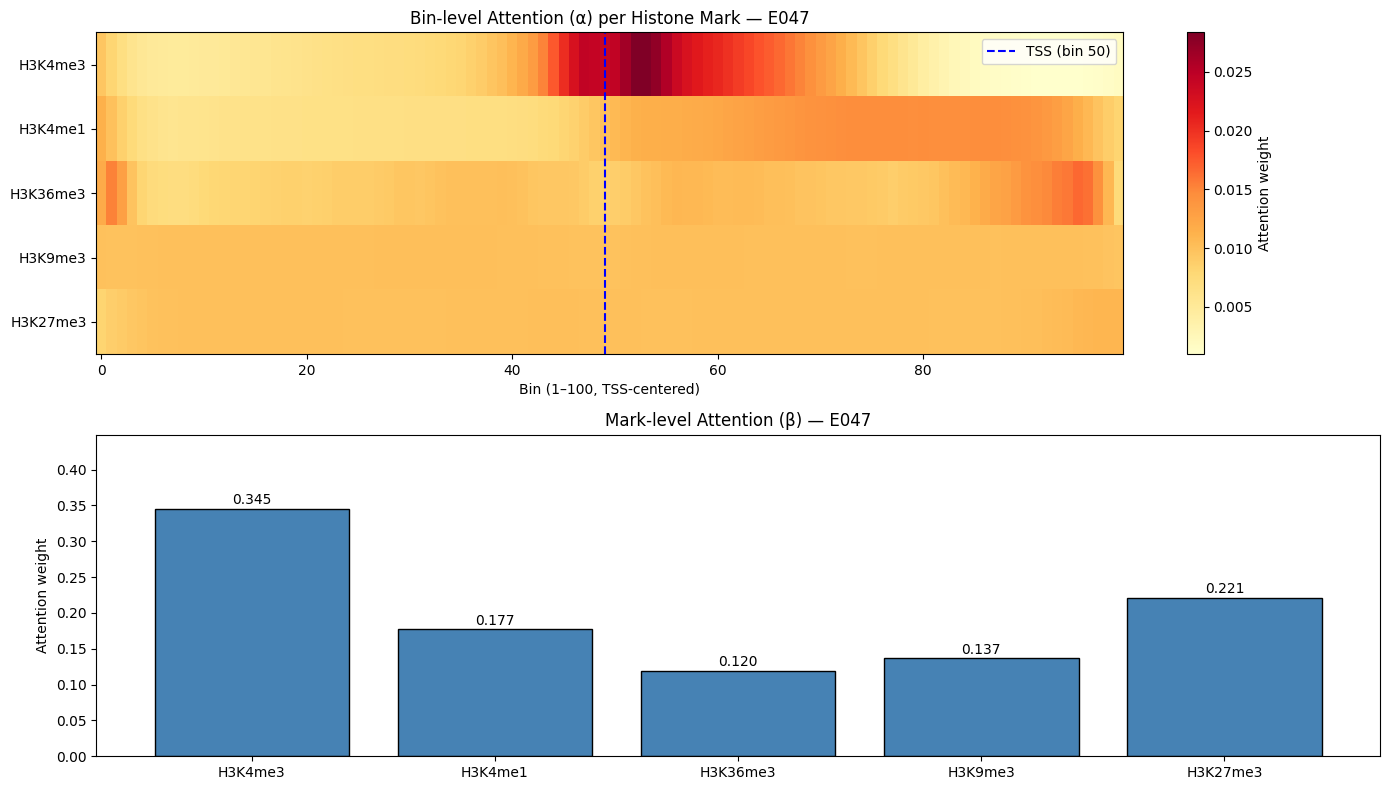

In [18]:
import matplotlib.pyplot as plt

mark_names = ['H3K4me3', 'H3K4me1', 'H3K36me3', 'H3K9me3', 'H3K27me3']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

#Alpha heatmap (bin-level attention)
im = axes[0].imshow(avg_bin_alphas, aspect='auto', cmap='YlOrRd')
axes[0].set_yticks(range(5))
axes[0].set_yticklabels(mark_names)
axes[0].set_xlabel('Bin (1–100, TSS-centered)')
axes[0].set_title('Bin-level Attention (α) per Histone Mark — E047')
plt.colorbar(im, ax=axes[0], label='Attention weight')

# Add TSS marker at bin 50
axes[0].axvline(x=49, color='blue', linestyle='--', linewidth=1.5, label='TSS (bin 50)')
axes[0].legend(loc='upper right')

# Beta bar chart (mark-level attention)
bars = axes[1].bar(mark_names, avg_beta, color='steelblue', edgecolor='black')
axes[1].set_ylabel('Attention weight')
axes[1].set_title('Mark-level Attention (β) — E047')
axes[1].set_ylim(0, avg_beta.max() * 1.3)

# Add value labels on bars
for bar, val in zip(bars, avg_beta):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('attentivechrome_attention_e047.png', dpi=150, bbox_inches='tight')
plt.show()